<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/PortfolioAnalysis/PortfolioAnalysis/Risk_Parity_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [ ]:
tickers = ["AAPL", "MSFT", "TSLA"]
start_date = "2020-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
data.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,TSLA
Date,,,
2020-01-02,72.468246,152.505676,28.684000
2020-01-03,71.763725,150.606766,29.534000
2020-01-06,72.335571,150.996017,30.102667
2020-01-07,71.995361,149.619278,31.270666
2020-01-08,73.153488,152.002457,32.809334


In [ ]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,MSFT,TSLA
Date,,,
2020-01-03,-0.009722,-0.012451,0.029633
2020-01-06,0.007968,0.002585,0.019255
2020-01-07,-0.004703,-0.009118,0.038801
2020-01-08,0.016086,0.015928,0.049205
2020-01-09,0.021241,0.012493,-0.021945


In [ ]:
weights = np.array([1/3, 1/3, 1/3])
returns['Portfolio'] = returns.dot(weights)
returns.head()

Ticker,AAPL,MSFT,TSLA,Portfolio
Date,,,,
2020-01-03,-0.009722,-0.012451,0.029633,0.002487
2020-01-06,0.007968,0.002585,0.019255,0.009936
2020-01-07,-0.004703,-0.009118,0.038801,0.008327
2020-01-08,0.016086,0.015928,0.049205,0.027073
2020-01-09,0.021241,0.012493,-0.021945,0.003930


In [ ]:
cov_matrix = returns[tickers].cov() * 252  # annualized covariance

In [ ]:
n_assets = len(tickers)
initial_guess = np.repeat(1/n_assets, n_assets)
bounds = [(0, 1)] * n_assets
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

result = minimize(risk_parity_objective, initial_guess,
                  args=(cov_matrix,), bounds=bounds,
                  constraints=constraints,
                  method='SLSQP')

risk_parity_weights = result.x
print("Risk Parity Weights:", risk_parity_weights)

Risk Parity Weights: [0.3952312  0.40020352 0.20456527]


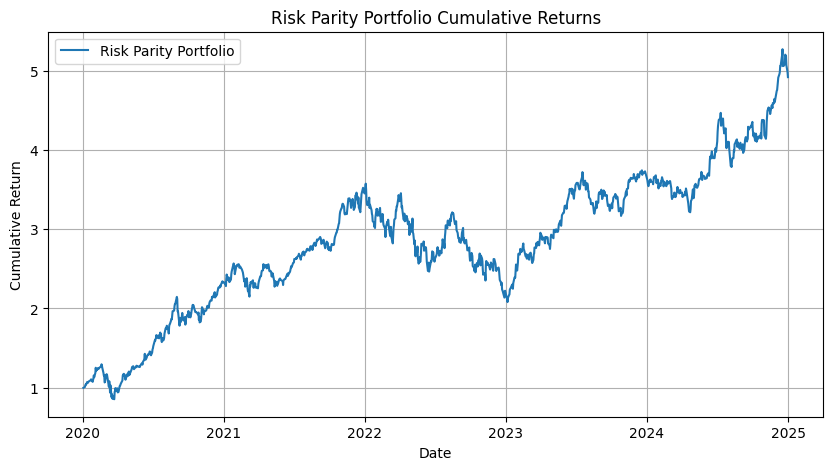

In [ ]:
returns['RiskParity'] = returns[tickers].dot(risk_parity_weights)
cumulative = (1 + returns['RiskParity']).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cumulative, label='Risk Parity Portfolio')
plt.title('Risk Parity Portfolio Cumulative Returns')
plt.xlabel('Date'); plt.ylabel('Cumulative Return')
plt.legend(); plt.grid(True)
plt.show()